In [1]:
import numpy as np
import pandas as pd
import lasio as las
from glob import glob
import importlib
import matplotlib.pyplot as plt
import torch as pt
import gpytorch
import scipy
import os

from util.filehandler import read_las, save_gp_model, load_gp_model
from util.plotting import plot_well_logs, visualize_multichannel_gp_results_side_by_side, visualize_single_gp_result
from util.well_processing import filter_wells_by_lithology, prepare_valid_tagilsk
from util.gaussian_processes import fit_gp_model_all_wells, predict_gp_model, fit_gp_model

%load_ext autoreload
%autoreload 2


In [2]:
las_files = glob('//mnt/Documents/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/*Tgl*.las')
# las_files = glob('../data/las/*Tgl*.las')
las_files

['//mnt/Documents/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-30.las',
 '//mnt/Documents/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-26.las',
 '//mnt/Documents/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/ZTgl-1.las',
 '//mnt/Documents/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-15.las',
 '//mnt/Documents/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-29.las',
 '//mnt/Documents/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-8.las',
 '//mnt/Documents/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-27.las']

In [3]:
# Create a dictionary to store all DataFrames
las_dfs = read_las(las_files)
# Keep only needed curves
las_dfs = prepare_valid_tagilsk(las_dfs)
# Display the keys (well names) in the dictionary
# del las_dfs['ZTgl-1']
print(f"\nTotal wells loaded: {len(las_dfs)}")
print(f"Well names: {list(las_dfs.keys())}")

Loaded: Tgl-30 - 4603 rows, 14 curves
Loaded: Tgl-26 - 6062 rows, 15 curves
Loaded: ZTgl-1 - 5408 rows, 12 curves
Loaded: Tgl-15 - 5898 rows, 14 curves
Loaded: Tgl-29 - 29873 rows, 14 curves
Loaded: Tgl-8 - 7623 rows, 16 curves
Loaded: Tgl-27 - 2377 rows, 12 curves
Processing well Tgl-30
Processing well Tgl-26
Processing well ZTgl-1
Processing well Tgl-15
Processing well Tgl-29
Processing well Tgl-8
Processing well Tgl-27

Total wells loaded: 7
Well names: ['Tgl-30', 'Tgl-26', 'ZTgl-1', 'Tgl-15', 'Tgl-29', 'Tgl-8', 'Tgl-27']


/home/spaceswimmer/miniconda3/envs/diploma/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Processing wells, deleting trash data
### Manual trash data deletion

In [4]:
# Manual trash data deletion
# Tgl-29
mask = (las_dfs['Tgl-29']['DEPTH'] < 3700) & (las_dfs['Tgl-29']['DEPTH'] > 3000)
las_dfs['Tgl-29'].loc[mask, 'DTP'] = np.nan
mask = (las_dfs['Tgl-29']['DEPTH'] < 3700) & (las_dfs['Tgl-29']['DEPTH'] > 2398)
las_dfs['Tgl-29'].loc[mask, 'DTS'] = np.nan
# ZTgl-1
mask = (las_dfs['ZTgl-1']['DEPTH'] < 3150) & (las_dfs['ZTgl-1']['DEPTH'] > 2964)
las_dfs['ZTgl-1'].loc[mask, 'PL_GG'] = np.nan
# Tgl-8
mask = (las_dfs['Tgl-8']['DEPTH'] < 3150) & (las_dfs['Tgl-8']['DEPTH'] > 1846)
las_dfs['Tgl-8'].loc[mask, 'DTP'] = np.nan
mask = (las_dfs['Tgl-8']['DEPTH'] < 2656) & (las_dfs['Tgl-8']['DEPTH'] > 1840)
las_dfs['Tgl-8'].loc[mask, 'PL_GG'] = np.nan
# ZTgl-1
mask = (las_dfs['Tgl-27']['DEPTH'] < 3200) & (las_dfs['Tgl-27']['DEPTH'] > 1590)
las_dfs['Tgl-27'].loc[mask, 'DTP'] = np.nan
las_dfs = prepare_valid_tagilsk(las_dfs)

Processing well Tgl-30
Processing well Tgl-26
Processing well ZTgl-1
Processing well Tgl-15
Processing well Tgl-29
Processing well Tgl-8
Processing well Tgl-27


/home/spaceswimmer/miniconda3/envs/diploma/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
# test = las_dfs['Tgl-27'][
#     (las_dfs['Tgl-27']['DEPTH'] < 3200) & 
#     (las_dfs['Tgl-27']['DEPTH'] > 1590)
# ]

(<Figure size 850x1200 with 5 Axes>,
 array([<Axes: title={'center': 'NAS'}, ylabel='Depth (m)'>,
        <Axes: title={'center': 'LITH'}>, <Axes: title={'center': 'DTP'}>,
        <Axes: title={'center': 'DTS'}>, <Axes: title={'center': 'PL_GG'}>],
       dtype=object))

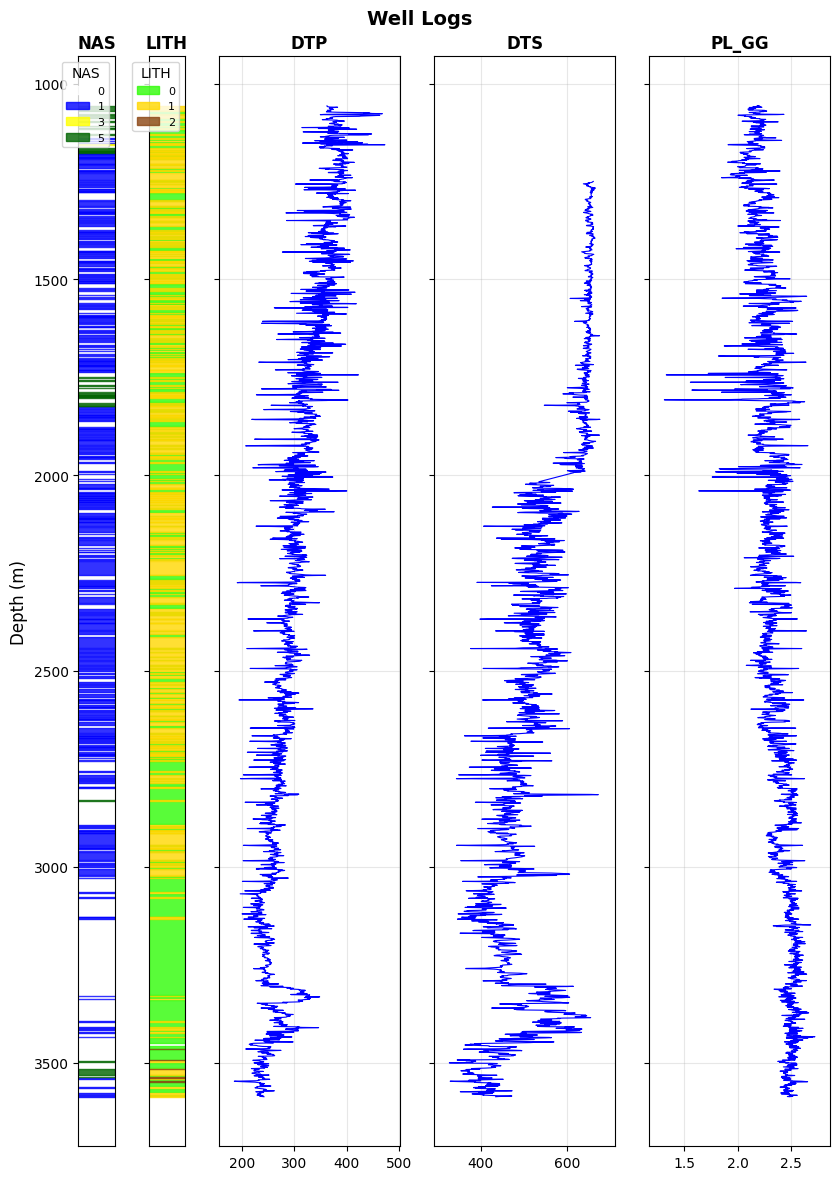

In [5]:
plot_well_logs(las_dfs['Tgl-30'], ['NAS', 'LITH', 'DTP', 'DTS', 'PL_GG'])

In [6]:
las_dfs_shale = {}
las_dfs_brine_sand = {}
las_dfs_oil_sand = {}
las_dfs_gas_sand = {}

# Apply filtering to all wells
las_dfs_shale, las_dfs_brine_sand, las_dfs_oil_sand, las_dfs_gas_sand = filter_wells_by_lithology(las_dfs)

Tgl-30: shale=2260, brine=1707, oil=142, gas=4
Tgl-26: shale=2806, brine=2255, oil=446, gas=94
ZTgl-1: shale=2184, brine=2217, oil=0, gas=0
Tgl-15: shale=2430, brine=1939, oil=427, gas=285
Tgl-29: shale=15536, brine=12102, oil=1081, gas=194
Tgl-8: shale=3158, brine=723, oil=1774, gas=55
Tgl-27: shale=848, brine=46, oil=215, gas=34


# Probabalistic models implementation

In [8]:
# from util.gaussian_processes_sklearn import fit_gp_model_sklearn
# from util.plotting import plot_gp_model

# result = fit_gp_model_sklearn(las_dfs_shale['Tgl-30'], 'VP')
# plot_gp_model(result, 'VP')

## shale

Using 29222 total points for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']
['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: subsampled to 1000 points


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:   4%|▍         | 2/50 [00:00<00:07,  6.66it/s]

Iteration 0, Loss: 1.3162


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  44%|████▍     | 22/50 [00:02<00:03,  9.00it/s]

Iteration 20, Loss: 1.1274


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  84%|████████▍ | 42/50 [00:04<00:00,  9.00it/s]

Iteration 40, Loss: 1.1144


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: 100%|██████████| 50/50 [00:05<00:00,  8.83it/s]


['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: trained on 1000 points


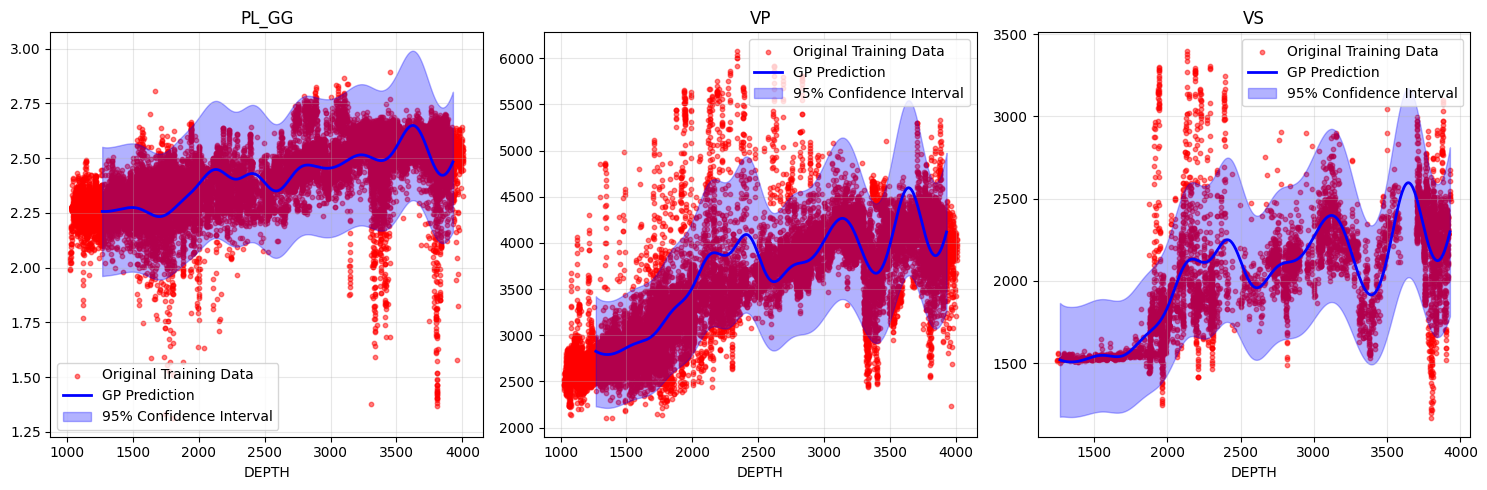

In [ ]:
result = fit_gp_model_all_wells(
las_dfs_shale,
property_col=['PL_GG_LOG', 'VP_LOG', 'VS_LOG'],
max_points=5000,
training_iter=50,
lengthscale=0.2
)
all_data = []
for well_name, data in las_dfs_shale.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_multichannel_gp_results_side_by_side(result, ['PL_GG', 'VP', 'VS'], combined_df, log_transform=True)
save_gp_model(result, f"../data/models/shale_pl_vp_vs_5000pt.pth")

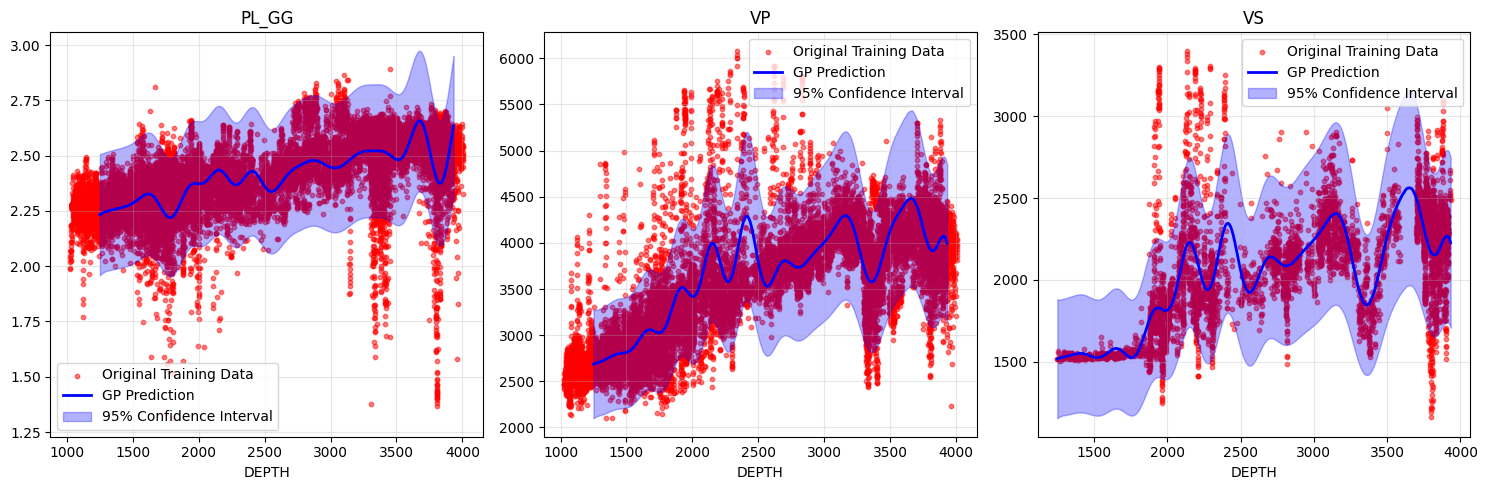

In [11]:
test = load_gp_model("../data/models/shale_pl_vp_vs.pth")
visualize_multichannel_gp_results_side_by_side(test, ['PL_GG', 'VP', 'VS'], combined_df, log_transform=True)

## brine

In [ ]:
result['model'].train_targets.cpu()[:, 0]

torch.Size([1000, 3])

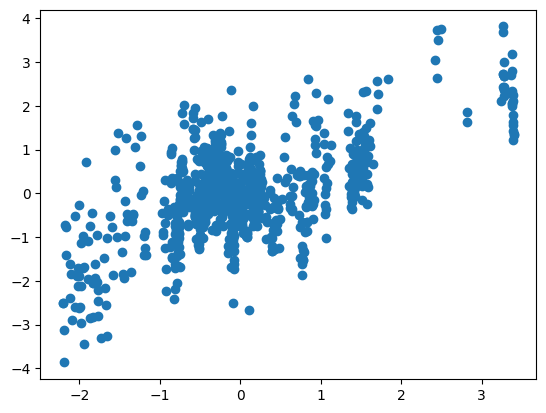

In [31]:
plt.scatter(result['model'].train_inputs[0].cpu(), result['model'].train_targets.cpu()[:, 0])

Using 20989 total points for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']
['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: subsampled to 5000 points


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:   2%|▏         | 1/50 [00:05<04:13,  5.17s/it]

Iteration 0, Loss: 1.2273


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  42%|████▏     | 21/50 [01:47<02:33,  5.30s/it]

Iteration 20, Loss: 0.8542


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  82%|████████▏ | 41/50 [03:28<00:47,  5.23s/it]

Iteration 40, Loss: 0.7967


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: 100%|██████████| 50/50 [04:13<00:00,  5.07s/it]


['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: trained on 5000 points


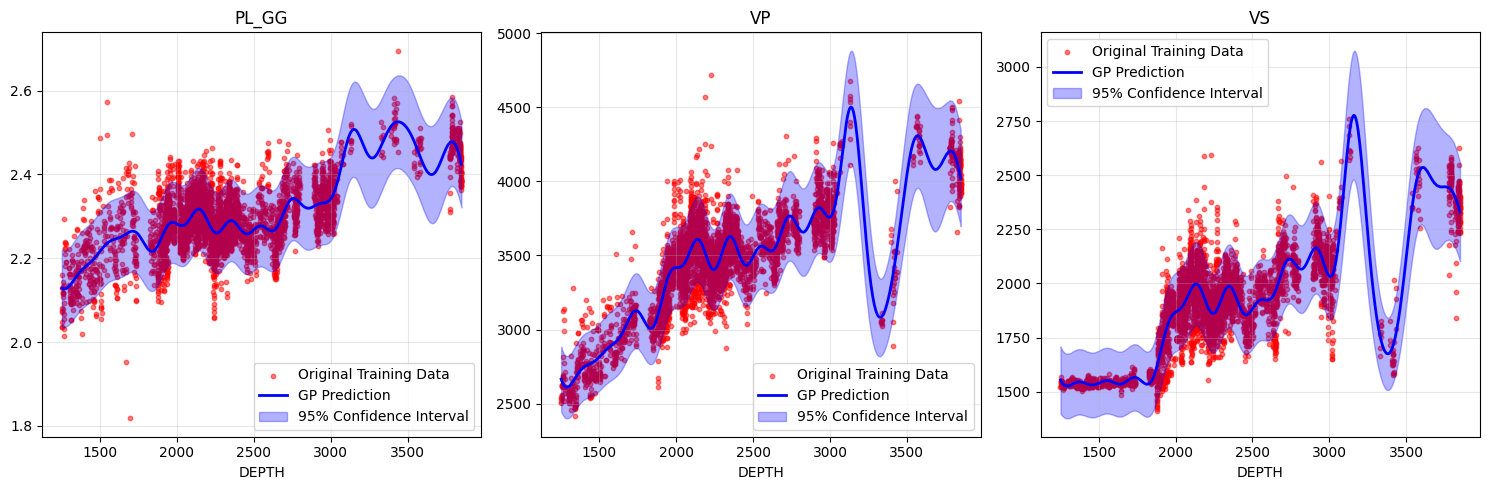

In [11]:
result = fit_gp_model_all_wells(
las_dfs_brine_sand,
property_col=['PL_GG_LOG', 'VP_LOG', 'VS_LOG'],
max_points=5000,
training_iter=50,
lengthscale=0.3
)
all_data = []
for well_name, data in las_dfs_brine_sand.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_multichannel_gp_results_side_by_side(result, ['PL_GG', 'VP', 'VS'], combined_df.dropna(), log_transform=True)    
save_gp_model(result, f"../data/models/brine_pl_vp_vs.pth")

## oil
### PL_GG

Using 4085 total points for PL_GG_LOG


Training GP for PL_GG_LOG:   2%|▏         | 1/50 [00:00<00:05,  8.91it/s]

Iteration 0, Loss: 0.9878


Training GP for PL_GG_LOG:  54%|█████▍    | 27/50 [00:00<00:00, 44.94it/s]

Iteration 20, Loss: 0.8600


Training GP for PL_GG_LOG:  94%|█████████▍| 47/50 [00:01<00:00, 43.30it/s]

Iteration 40, Loss: 0.8316


Training GP for PL_GG_LOG: 100%|██████████| 50/50 [00:01<00:00, 42.21it/s]


PL_GG_LOG: trained on 2955 points


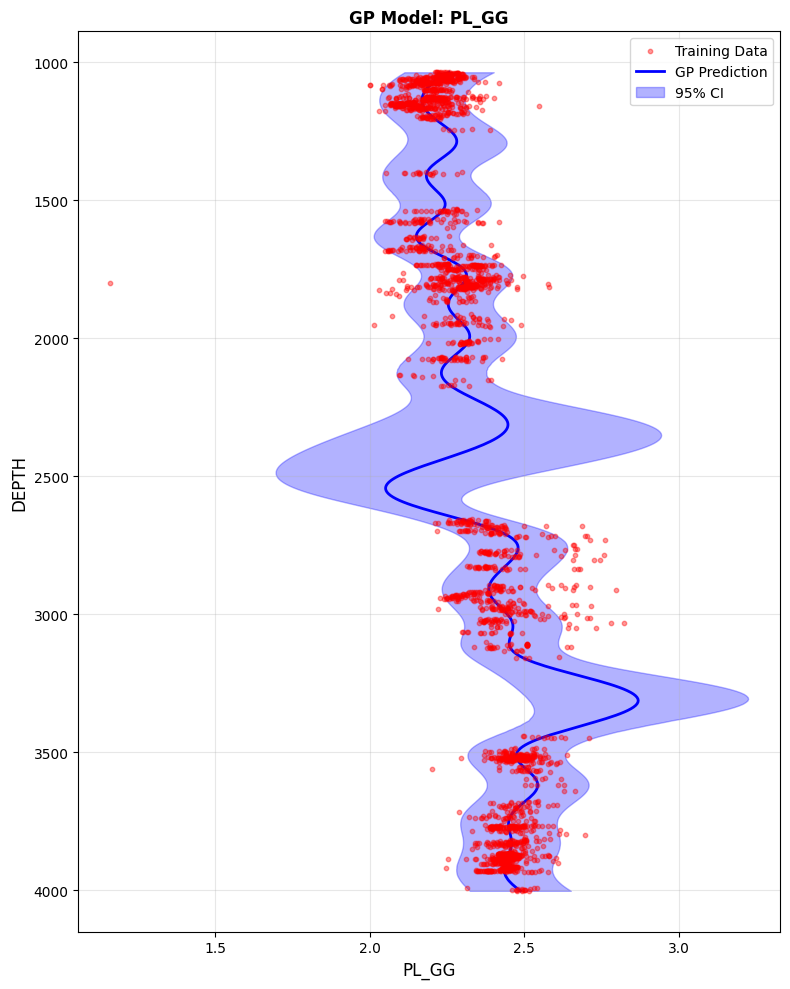

In [ ]:
result = fit_gp_model_all_wells(
las_dfs_oil_sand,
property_col='PL_GG_LOG',
max_points=None,
training_iter=50,
lengthscale=0.1
)
all_data = []
for well_name, data in las_dfs_oil_sand.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_single_gp_result(result, 'PL_GG', combined_df, log_transform=True)   


### VS

Using 4085 total points for VS_LOG


Training GP for VS_LOG:  28%|██▊       | 14/50 [00:00<00:00, 139.78it/s]

Iteration 0, Loss: 0.8588
Iteration 20, Loss: 0.3989


Training GP for VS_LOG: 100%|██████████| 50/50 [00:00<00:00, 207.70it/s]

Iteration 40, Loss: 0.3436
VS_LOG: trained on 559 points


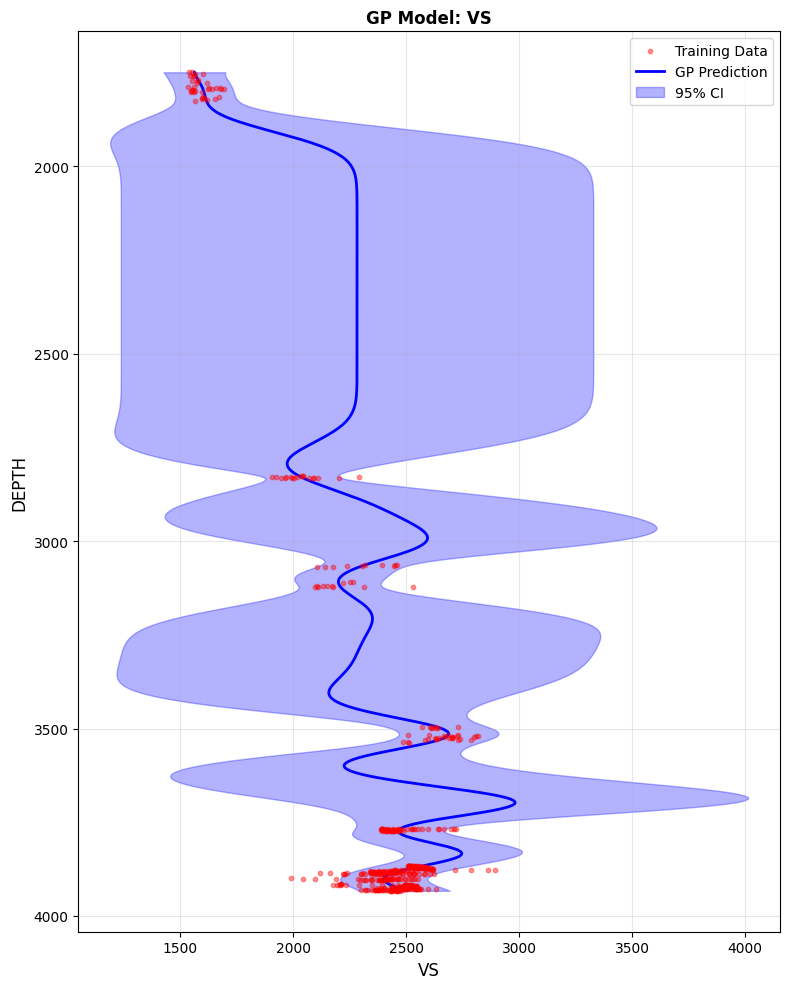

In [ ]:
result = fit_gp_model_all_wells(
las_dfs_oil_sand,
property_col='VS_LOG',
max_points=None,
training_iter=50,
lengthscale=0.1
)
all_data = []
for well_name, data in las_dfs_oil_sand.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_single_gp_result(result, 'VS', combined_df, log_transform=True)   


### VP

Using 4085 total points for VP_LOG


Training GP for VP_LOG:  14%|█▍        | 7/50 [00:00<00:00, 59.76it/s]

Iteration 0, Loss: 0.8128


Training GP for VP_LOG:  62%|██████▏   | 31/50 [00:00<00:00, 52.85it/s]

Iteration 20, Loss: 0.2505


Training GP for VP_LOG: 100%|██████████| 50/50 [00:00<00:00, 51.40it/s]

Iteration 40, Loss: 0.1885
VP_LOG: trained on 2349 points


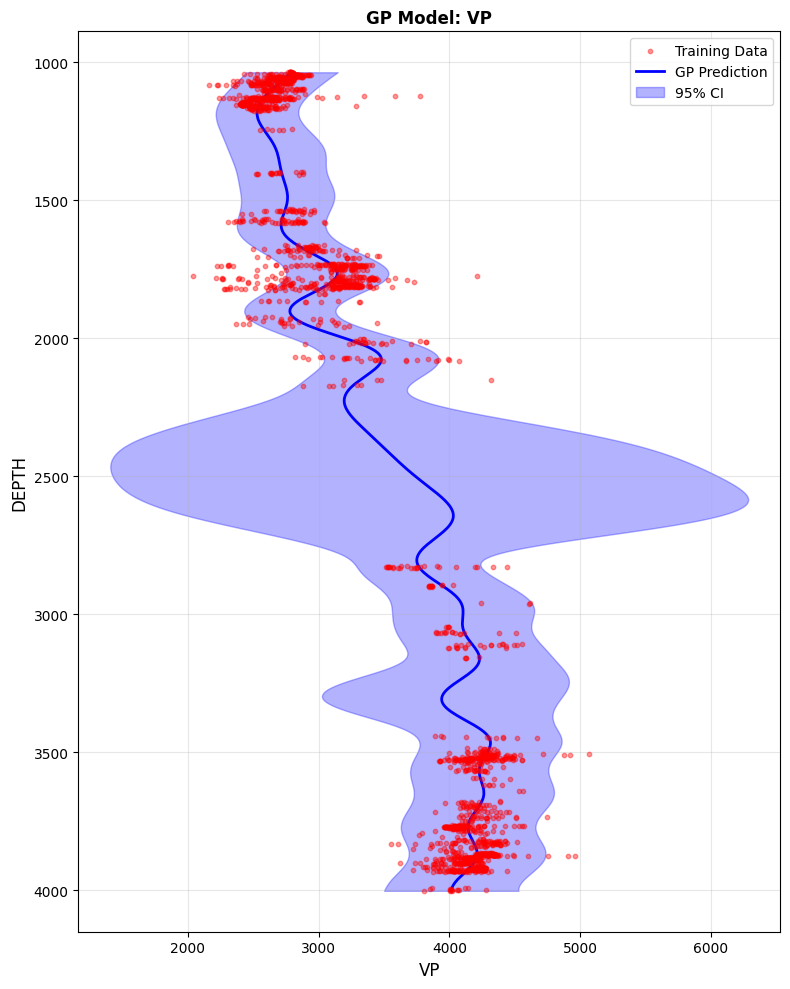

In [ ]:
result = fit_gp_model_all_wells(
las_dfs_oil_sand,
property_col='VP_LOG',
max_points=None,
training_iter=50,
lengthscale=0.1
)
all_data = []
for well_name, data in las_dfs_oil_sand.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_single_gp_result(result, 'VP', combined_df, log_transform=True)


### Combined?

In [8]:
result = fit_gp_model_all_wells(
las_dfs_oil_sand,
property_col=['PL_GG_LOG', 'VP_LOG', 'VS_LOG'],
max_points=None,
training_iter=50,
lengthscale=0.1
)
all_data = []
for well_name, data in las_dfs_oil_sand.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_multichannel_gp_results_side_by_side(result, ['PL_GG', 'VP', 'VS'], combined_df, log_transform=True)  

Using 4085 total points for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']


UnboundLocalError: cannot access local variable 'data' where it is not associated with a value

Looks like shit but whatever

### linear regression for interpolation

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

def predict_missing_vs(df):
    """
    Predict missing VS values using VP and PL_GG correlations
    Only predicts where both VP and PL_GG values exist
    """
    # Prepare features (VP and PL_GG) and target (VS)
    feature_cols = ['VP_LOG', 'PL_GG_LOG']
    target_col = 'VS_LOG'
    
    # Create mask for rows where we have VS values and both features are available
    has_vs_mask = df[target_col].notna()
    has_both_features = df[feature_cols].notna().all(axis=1)
    
    # Separate training data (rows with VS and both features)
    train_features = df.loc[has_vs_mask & has_both_features, feature_cols]
    train_target = df.loc[has_vs_mask & has_both_features, target_col]
    
    # Get rows where we need to predict VS (VS is missing but both features are available)
    predict_mask = df[target_col].isna() & df[feature_cols].notna().all(axis=1)
    predict_features = df.loc[predict_mask, feature_cols]
    
    # Only proceed if we have both training data and prediction targets
    if len(train_features) > 5 and len(predict_features) > 0:  # Minimum threshold
        # Handle missing values in features by imputing
        imputer = SimpleImputer(strategy='mean')
        
        # Fit and transform training features
        train_features_clean = imputer.fit_transform(train_features)
        
        # Transform prediction features using same imputer
        predict_features_clean = imputer.transform(predict_features)
        
        # Train linear regression model
        model = LinearRegression()
        model.fit(train_features_clean, train_target)
        
        # Predict missing VS values
        predicted_vs = model.predict(predict_features_clean)
        
        # Create a copy of the dataframe and update VS values
        df_result = df.copy()
        df_result.loc[predict_mask, target_col] = predicted_vs
        
        return df_result
    
    else:
        print("Not enough data points with VS values to build a predictive model")
        return df

# Usage example:
all_data = []
for well_name, data in las_dfs_oil_sand.items():
    app_data = data[['DEPTH', 'VP_LOG', 'VS_LOG', 'PL_GG_LOG', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
df_with_predicted_vs = predict_missing_vs(combined_df)

(<Figure size 750x1200 with 3 Axes>,
 array([<Axes: title={'center': 'VP_LOG'}, ylabel='Depth (m)'>,
        <Axes: title={'center': 'VS_LOG'}>,
        <Axes: title={'center': 'PL_GG_LOG'}>], dtype=object))

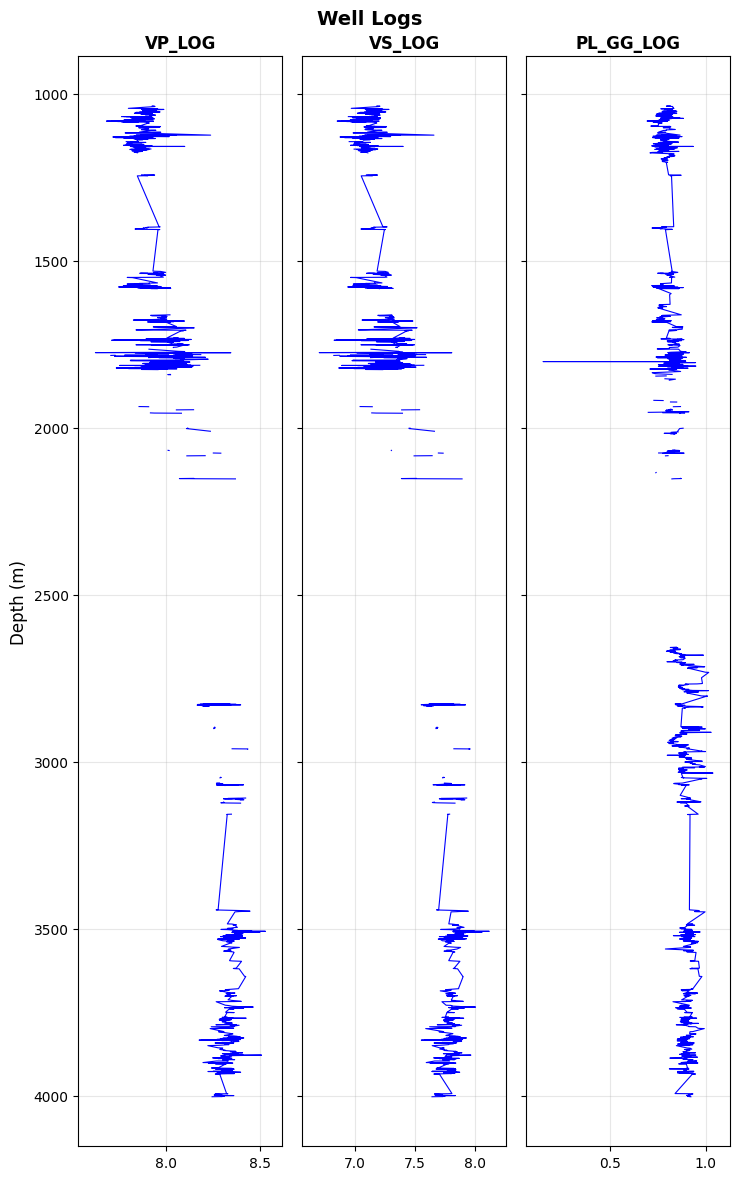

In [22]:
plot_well_logs(df_with_predicted_vs, ['VP_LOG', 'VS_LOG', 'PL_GG_LOG'])

In [28]:
df_with_predicted_vs

,DEPTH,VP_LOG,VS_LOG,PL_GG_LOG,VP,VS,PL_GG
0,1057.018799,7.923738,7.196856,0.786146,2762.077472,NaN,2.194922
1,1057.628418,7.923424,7.200504,0.777964,2761.208858,NaN,2.177035
2,1058.237915,7.920628,7.189111,0.791558,2753.499140,NaN,2.206832
3,1058.847656,7.921629,7.202449,0.768448,2756.256904,NaN,2.156417
4,1059.457153,7.913824,7.185513,0.777105,2734.827251,NaN,2.175166
...,...,...,...,...,...,...,...
4080,3110.000000,NaN,NaN,0.871712,NaN,NaN,2.391000
4081,3120.000000,NaN,NaN,0.849296,NaN,NaN,2.338000
4082,3510.000000,8.350772,7.844317,0.862468,4233.449249,NaN,2.369000
4083,3520.000000,8.303858,7.785037,0.830733,4039.424826,NaN,2.295000


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:   2%|▏         | 1/50 [00:01<00:53,  1.08s/it]

Iteration 0, Loss: 1.1428


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  42%|████▏     | 21/50 [00:16<00:23,  1.25it/s]

Iteration 20, Loss: 0.5139


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  82%|████████▏ | 41/50 [00:32<00:07,  1.26it/s]

Iteration 40, Loss: 0.3903


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: 100%|██████████| 50/50 [00:39<00:00,  1.28it/s]


['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: trained on 2347 points


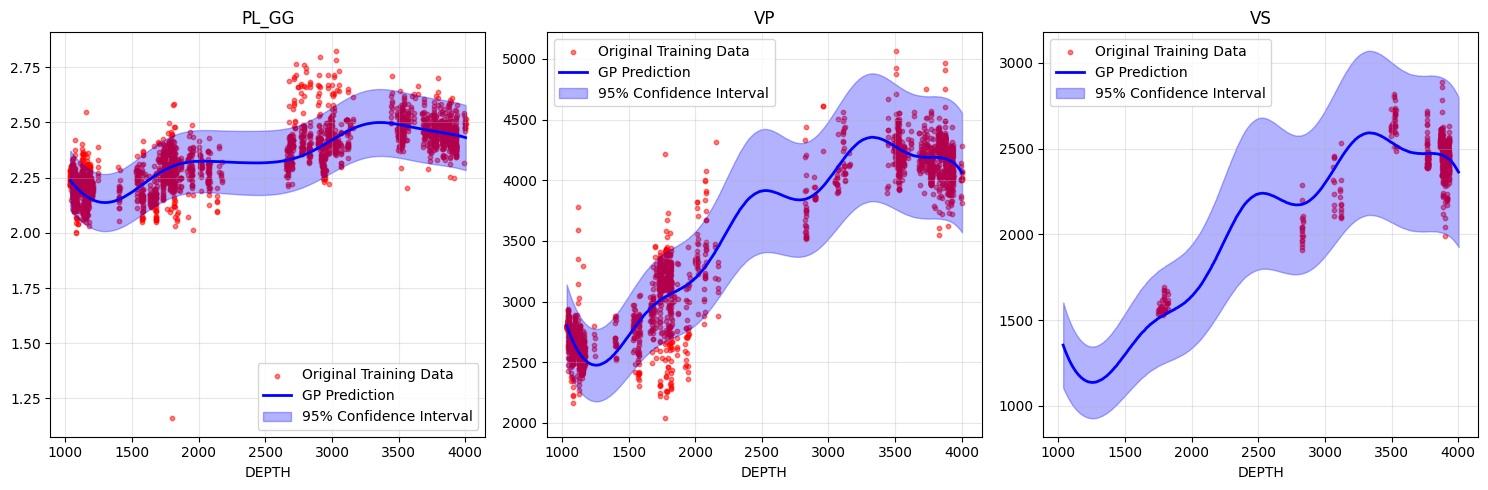

In [25]:
result = fit_gp_model(
df_with_predicted_vs,
property_col=['PL_GG_LOG', 'VP_LOG', 'VS_LOG'],
max_points=None,
training_iter=50,
lengthscale=0.4
)
visualize_multichannel_gp_results_side_by_side(result, ['PL_GG', 'VP', 'VS'], df_with_predicted_vs, log_transform=True)
save_gp_model(result, f"../data/models/oil_pl_vp_vs.pth")

## gas

Using 666 total points for ['PL_GG_LOG', 'VP_LOG']


Training GP for ['PL_GG_LOG', 'VP_LOG']:   4%|▍         | 2/50 [00:00<00:02, 18.33it/s]

Iteration 0, Loss: 1.1947


Training GP for ['PL_GG_LOG', 'VP_LOG']:  50%|█████     | 25/50 [00:01<00:01, 22.31it/s]

Iteration 20, Loss: 0.7593


Training GP for ['PL_GG_LOG', 'VP_LOG']:  86%|████████▌ | 43/50 [00:01<00:00, 22.44it/s]

Iteration 40, Loss: 0.7437


Training GP for ['PL_GG_LOG', 'VP_LOG']: 100%|██████████| 50/50 [00:02<00:00, 22.03it/s]


['PL_GG_LOG', 'VP_LOG']: trained on 563 points


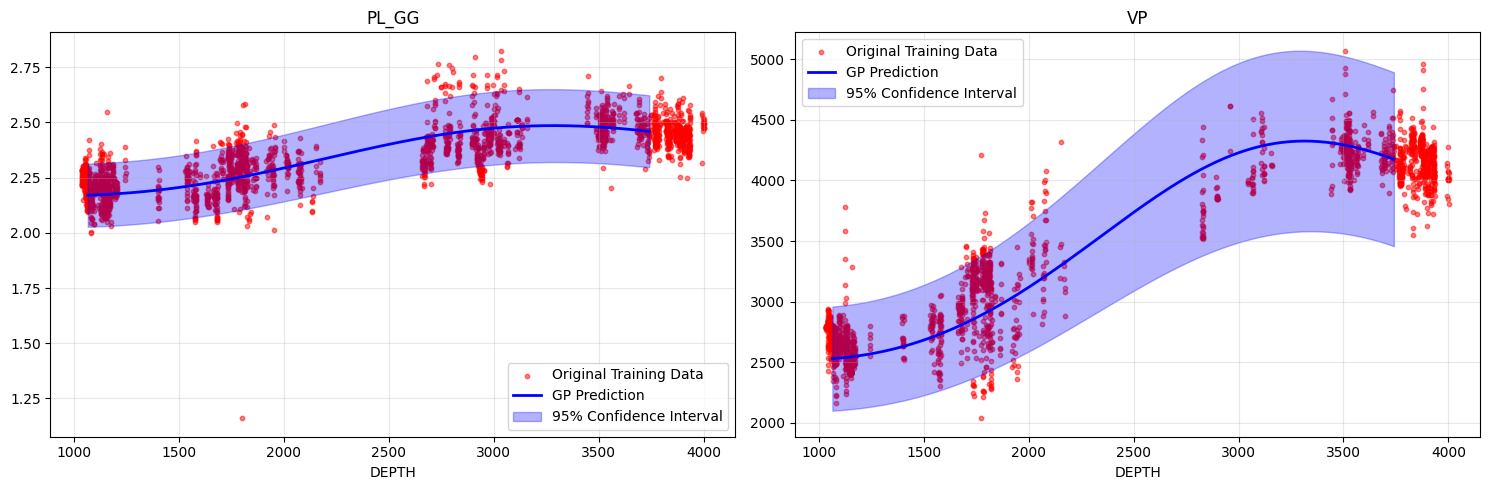

In [16]:
result = fit_gp_model_all_wells(
las_dfs_gas_sand,
property_col=['PL_GG_LOG', 'VP_LOG'],
max_points=None,
training_iter=50,
lengthscale=0.1
)
all_data = []
for well_name, data in las_dfs_oil_sand.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
# visualize_single_gp_result(result, 'VS', combined_df, log_transform=True)
visualize_multichannel_gp_results_side_by_side(result, ['PL_GG', 'VP'], df_with_predicted_vs, log_transform=True)
save_gp_model(result, f"../data/models/gas_pl_vp.pth")

# Testing predictions

In [7]:
def calc_oil_sand_vp(z):
    return -8.876e-06 * z**2 + 0.505 * z + 1998
def calc_oil_sand_rho(z):
        return -9.23e-09 * z**2 + 0.00014 * z + 1.916

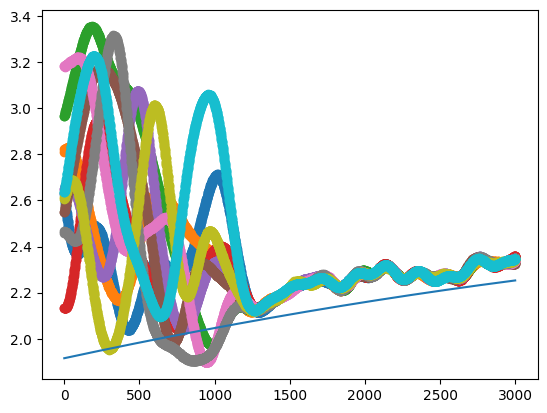

In [8]:
from util.gaussian_processes import sample_gp_model
brine_dict = load_gp_model('../data/models/brine_pl_vp_vs.pth')
x_new = np.arange(0, 3001, 1)
sample1 = sample_gp_model(brine_dict, x_new, log_transform=True, n_samples=10)
for i in range(0,10,1):
    plt.scatter(x_new, sample1[i, :, 0])
plt.plot(x_new, calc_oil_sand_rho(x_new))

In [20]:
np.max(sample1[i, :, 1])

np.float32(3845.7153)

In [19]:
np.exp(sample1[i, :, 1])

/tmp/ipykernel_122325/240716550.py:1: RuntimeWarning: overflow encountered in exp
  np.exp(sample1[i, :, 1])


array([inf, inf, inf, ..., inf, inf, inf], shape=(3001,), dtype=float32)

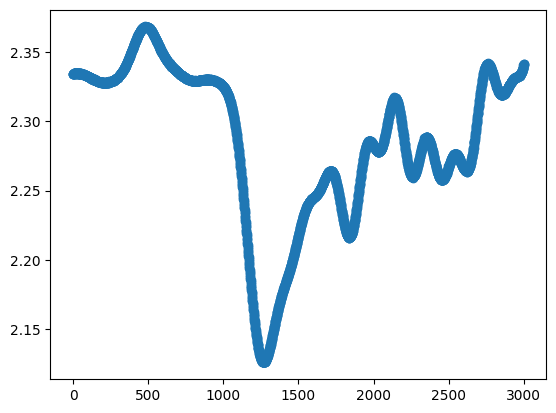

In [11]:
plt.scatter(x_new, np.mean(sample1, axis=0)[:, 0])

# Trash

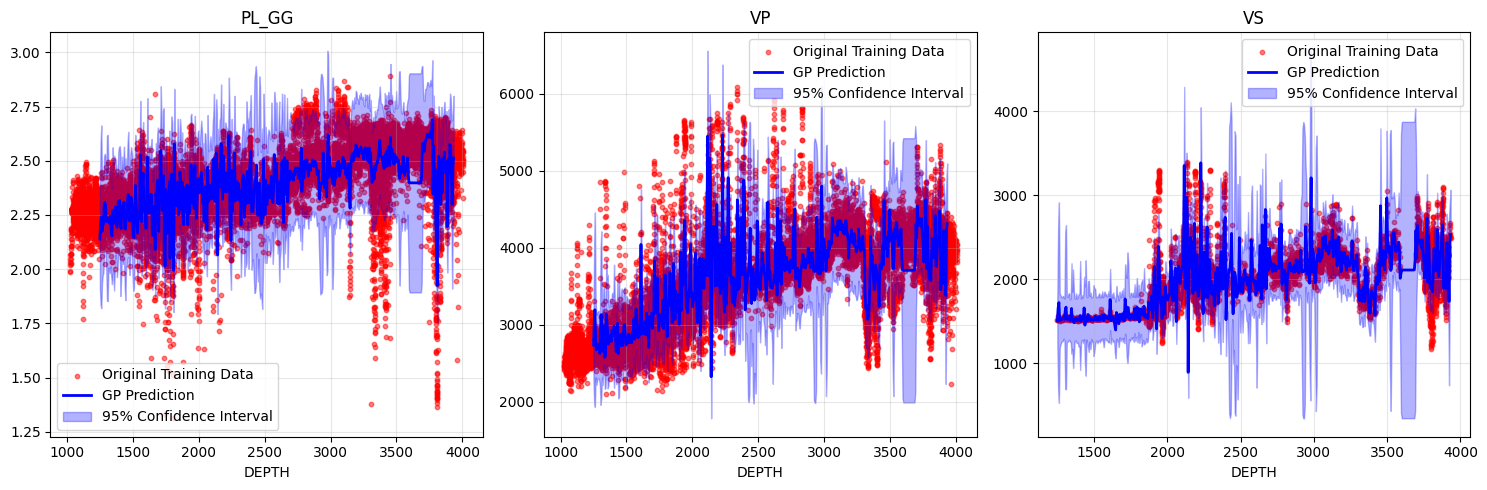

In [ ]:
all_data = []
for well_name, df in las_dfs_shale.items():
    app_data = df[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_multichannel_gp_results_side_by_side(result_shale, ['PL_GG', 'VP', 'VS'], combined_df, log_transform=True)    

In [39]:
from util.gaussian_processes import MultitaskGPModel
def save_gp_model(gp_result, filepath):
    """
    Save a GP model and its associated components to a file using PyTorch.
    
    Args:
        gp_result: Dictionary containing the GP model and related components
                   Expected keys: 'model', 'likelihood', 'scaler_x', 'scaler_y', 'depth_range'
        filepath: Path where the model should be saved
    """
    # Get the hyperparameters from the model
    model = gp_result['model']
    
    # Prepare the state dictionary with all necessary parameters
    state_dict = {
        'model_state_dict': model.state_dict(),
        'likelihood_state_dict': gp_result['likelihood'].state_dict(),
        'model_type': type(model).__name__,
        'num_tasks': getattr(model, 'num_tasks', 1),
        'scaler_x': gp_result['scaler_x'],
        'scaler_y': gp_result['scaler_y'],
        'depth_range': gp_result['depth_range']
    }
    
    # Save the state dictionary
    pt.save(state_dict, filepath)
    print(f"GP model saved to {filepath}")

save_gp_model(result_shale, '../data/models/shale_v1.pth')

GP model saved to ../data/models/shale_v1.pth


Tgl-30
Tgl-26
ZTgl-1
Tgl-15
Tgl-29
Tgl-8
Tgl-27


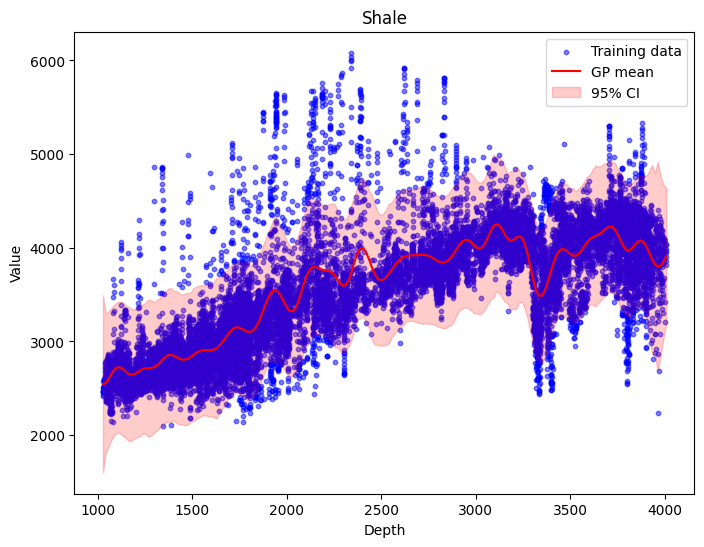

In [13]:
def plot_gp_result(gp_result: dict, x_train: np.ndarray, y_train: np.ndarray, title: str = None):
    """
    Simple plot of GP results with training data and uncertainty.
    
    Parameters
    ----------
    gp_result : dict
        Result from fit_gp_model()
    x_train : array
        Training depth values
    y_train : array
        Training property values
    title : str, optional
        Plot title
    """
    # Predict on smooth range
    x_range = np.linspace(gp_result['depth_range'][0], gp_result['depth_range'][1], 200)
    mean, std = predict_gp_model(gp_result, x_range)
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(x_train, y_train, c='blue', s=10, alpha=0.5, label='Training data')
    plt.plot(x_range, mean, 'r-', label='GP mean')
    plt.fill_between(x_range, mean - 2*std, mean + 2*std, alpha=0.2, color='red', label='95% CI')
    plt.xlabel('Depth')
    plt.ylabel('Value')
    if title:
        plt.title(title)
    plt.legend()
    plt.show()
all_data = []
    
for well_name, df in las_dfs_shale.items():
    app_data = df[['DEPTH', 'VP']]
    all_data.append(app_data)
    print(well_name)
combined_df = pd.concat(all_data, ignore_index=True)
plot_gp_result(result_shale, combined_df['DEPTH'], combined_df['VP'], title='Shale')

In [28]:
# Check what the model learned
result = result_shale['likelihood']
model = result_shale['model']

print("Model hyperparameters:")
print(f"  Lengthscale: {model.covar_module.base_kernel.lengthscale.item():.2f}")
print(f"  Output scale: {model.covar_module.outputscale.item():.2f}")
print(f"  Noise: {result.noise.item():.6f}")
print(f"  Mean constant: {model.mean_module.constant.item():.2f}")

Model hyperparameters:
  Lengthscale: 0.01
  Output scale: 4.19
  Noise: 0.308745
  Mean constant: -0.86


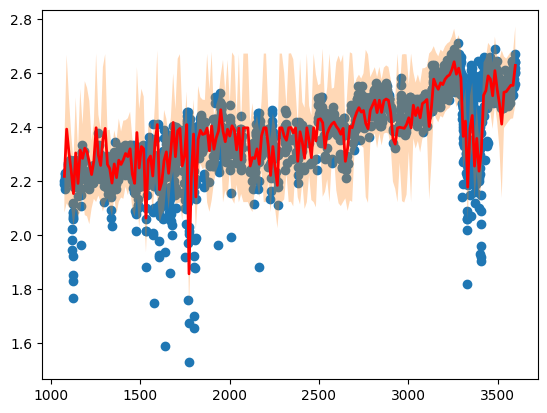

In [ ]:
x = las_dfs_shale['Tgl-15']['DEPTH']
y = las_dfs_shale['Tgl-15']['PL_GG']
x_smooth = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
y_mean, y_std = result['model'].predict(x_smooth, return_std=True)
plt.scatter(x, y)
plt.plot(x_smooth, y_mean, 'r-', label='GP Mean', linewidth=2)
plt.fill_between(x_smooth.flatten(), 
                y_mean - 2*y_std, 
                y_mean + 2*y_std, 
                alpha=0.3, label='±2σ')


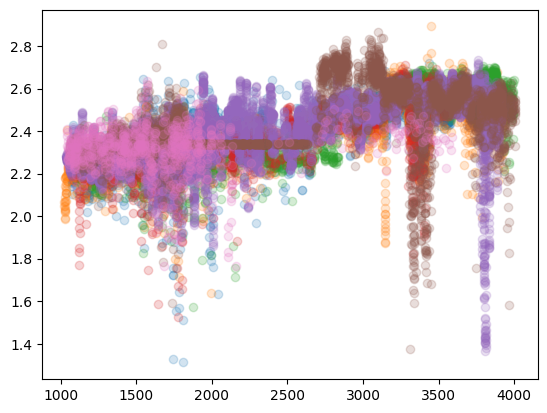

In [ ]:
for well in las_dfs_shale.keys():
    x = las_dfs_shale[well]['DEPTH']
    y = las_dfs_shale[well]['PL_GG']
    plt.scatter(x, y, alpha=0.2)